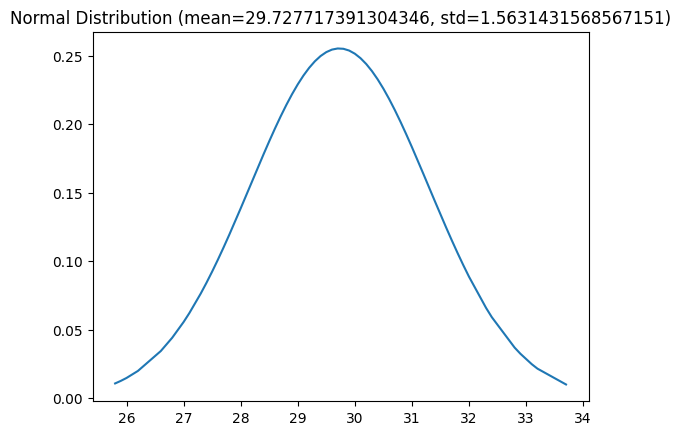

Probability is 0.5691416014012306


In [1]:
import sys
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import numpy as np
sys.path.append("/Users/gabriel/Desktop/Quant_Project/Quant-Summer-Project")

from data.fetcher import fetch_data
from data.cleaner import clean_data
from data.loader import add_event_column,filter_summer,get_separate_summer_months
from config.settings import HISTORICAL_START,HISTORICAL_END,DEFAULT_CITY
from scipy.stats import norm
from models.baseline import gaussian_probability


df_raw = fetch_data(HISTORICAL_START,HISTORICAL_END)


df_clean = clean_data(df_raw)


df_event = add_event_column(df_clean)


df_temp_summer = filter_summer(df_event)

df_temp_list = df_temp_summer["temperature_2m_max"].to_list()


df_sorted = sorted(df_temp_list)
P,my,sigma = gaussian_probability(df_sorted,20,30)


df_norm = norm.pdf(df_sorted,my,sigma)

plt.plot(df_sorted,df_norm)

plt.title(f'Normal Distribution (mean={my}, std={sigma})')
plt.show()
print(f"Probability is {P}")


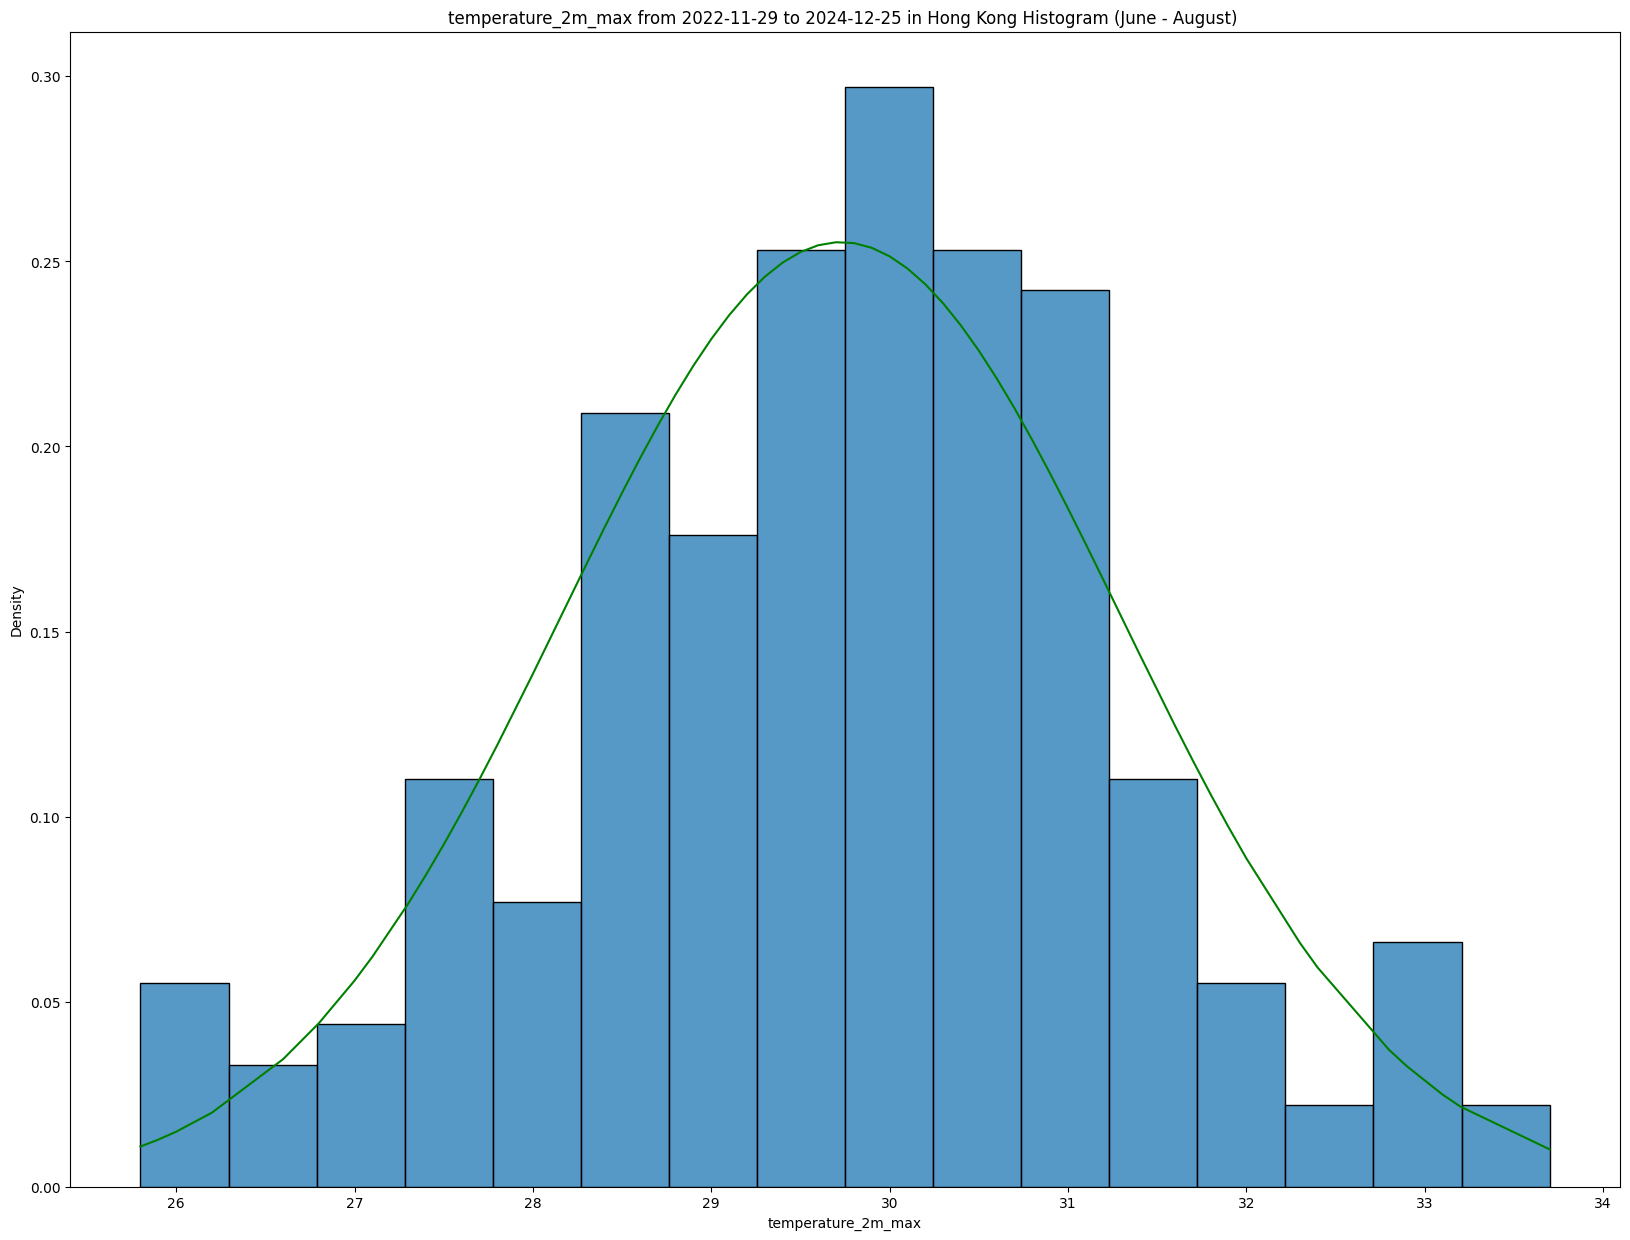

In [2]:
plt.figure(figsize =(20,15))
plt.title(f"temperature_2m_max from {HISTORICAL_START} to {HISTORICAL_END} in {DEFAULT_CITY} Histogram (June - August) ")
plt.xlabel("temperature_2m_max")
ax = sns.histplot( x= df_temp_list ,stat="density",binwidth=0.5)
a = df_sorted
b = df_norm
plt.plot(a,b,color = "green")
#plt.legend()
plt.show()


The bell curve fits very well with how the summer months are displayed. Which can be a hint that the baseline model will perform relatively well, but it only has two variables (sigma and my),so don't have the complexity that another model has that can see trends over time (climate change), extreme heat events and year to year variability which other models can predict these asymmetric behaviors.

<Axes: title={'center': 'temperature_2m_max from 2022-11-29 to 2024-12-25 in Hong Kong Histogram (August) '}, ylabel='Count'>

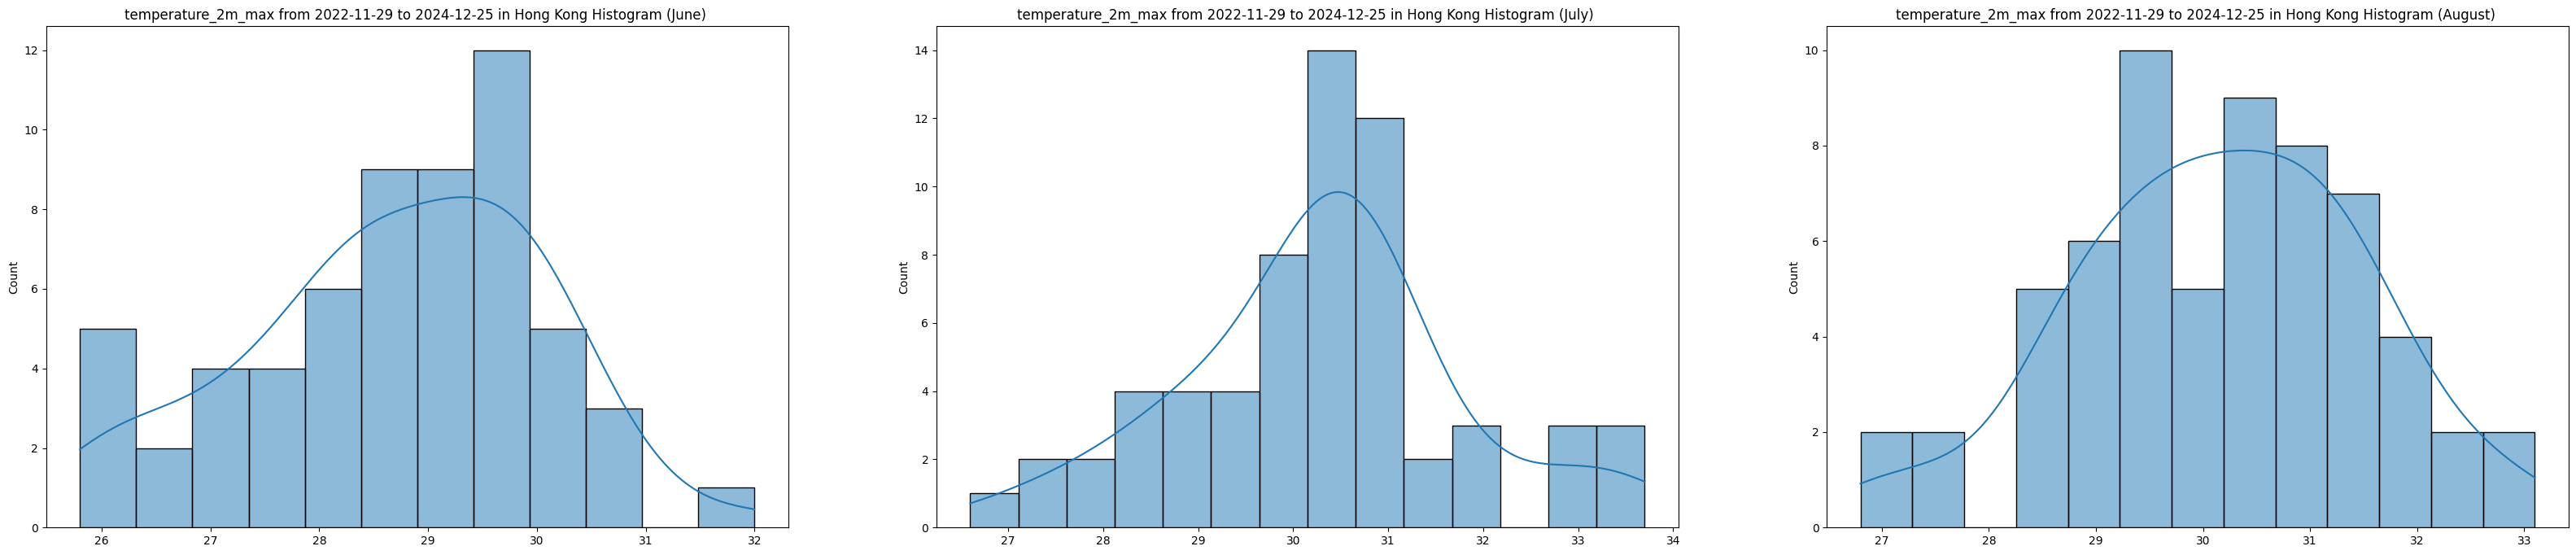

In [3]:
df_june,df_july,df_august = get_separate_summer_months(df_event)

df_june_list = df_june["temperature_2m_max"].to_list()
df_july_list = df_july["temperature_2m_max"].to_list()
df_august_list = df_august["temperature_2m_max"].to_list()
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(40, 8))

axes[0].set_title(f"temperature_2m_max from {HISTORICAL_START} to {HISTORICAL_END} in {DEFAULT_CITY} Histogram (June) ")
axes[1].set_title(f"temperature_2m_max from {HISTORICAL_START} to {HISTORICAL_END} in {DEFAULT_CITY} Histogram (July) ")
axes[2].set_title(f"temperature_2m_max from {HISTORICAL_START} to {HISTORICAL_END} in {DEFAULT_CITY} Histogram (August) ")
sns.histplot( x= df_june_list,binwidth=0.5,kde = True,ax=axes[0])
sns.histplot( x= df_july_list,binwidth=0.5,kde = True,ax=axes[1])
sns.histplot( x= df_august_list,binwidth=0.5,kde = True,ax=axes[2]) 



In June, we notice almost a spike, but the distribution remains reasonably symmetrical. July features a flat top, which indicates that there is an interval of values causing a plateau rather than a single value being significantly more common than the others. In August, we see that the central buckets sit above the bell curve. A single Gaussian model would not be suitable here, as it assumes all three months follow the same distribution, whereas they clearly differ.

To match Polymarket's actual Hong Kong market structure, gaussian_probability was generalized from a fixed bucket_center ± 0.5 window to explicit (lower_bound, upper_bound) arguments, where either side can be left open (None). This was necessary because the real market isn't made up of uniform symmetric buckets — the two extreme buckets are open-ended (e.g. "29°C or below", "39°C or higher"), so the function needed a way to represent an unbounded side.

We validated the generalized function two ways. First, complementary bounds were checked against each other directly: P(T ≤ 34.5) and P(T > 34.5) summed to exactly 1, confirming the open-below and open-above branches agree at a shared boundary. Second, we swept a full sequence of consecutive, non-overlapping 1°C buckets across the entire realistic temperature range and summed their probabilities — the total converged to ~1.0, confirming the bucket probabilities are internally consistent and that no probability mass is being double-counted or dropped. The baseline model's bucket logic is now correct for every bucket shape Polymarket can produce, not just the symmetric middle ones.